# Agent Training Dynamics

Analyze Q-Learning agent behavior during training

In [1]:
import sys
import os

# Determine the project root dynamically
def get_project_root():
    current_dir = os.getcwd()
    
    # Check if we're in the notebooks directory
    if os.path.basename(current_dir) == 'notebooks':
        return os.path.dirname(current_dir)
    
    return current_dir

# Add project root to Python path
project_root = get_project_root()
sys.path.insert(0, project_root)

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from src.environment import ScarseGridEnv
from src.agents import MultiAgentQLearning  # This should now work


Using device: cuda


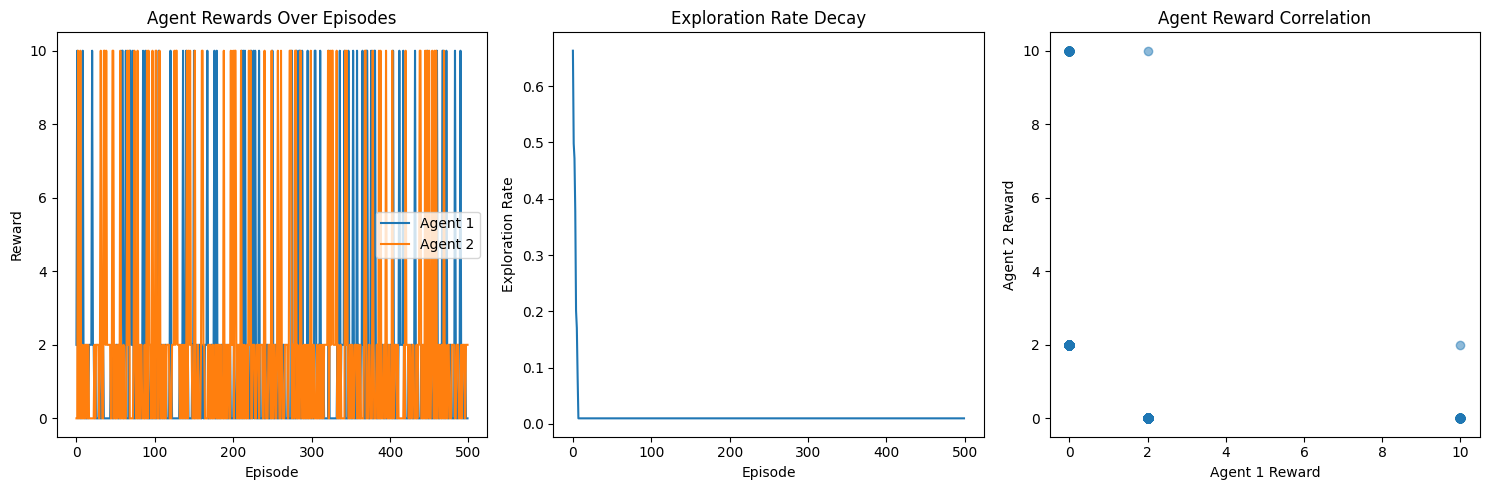

In [3]:
# Create environment
env = ScarseGridEnv(grid_size=5, seed_value=42)

# Initialize multi-agent trainer
multi_agent_trainer = MultiAgentQLearning(env)

# Training configuration
num_episodes = 500

# Training results tracking
training_results = {
    'episode': [],
    'agent1_reward': [],
    'agent2_reward': [],
    'exploration_rate': []
}

# Training loop
for episode in range(num_episodes):
    # Train for one episode
    agent_rewards = multi_agent_trainer.train(num_episodes=1)
    
    # Track results
    training_results['episode'].append(episode)
    training_results['agent1_reward'].append(agent_rewards[0][-1])
    training_results['agent2_reward'].append(agent_rewards[1][-1])
    training_results['exploration_rate'].append(
        multi_agent_trainer.agents[0].get_exploration_rate()
    )

# Convert to DataFrame for visualization
df = pd.DataFrame(training_results)

# Plotting
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(df['episode'], df['agent1_reward'], label='Agent 1')
plt.plot(df['episode'], df['agent2_reward'], label='Agent 2')
plt.title('Agent Rewards Over Episodes')
plt.xlabel('Episode')
plt.ylabel('Reward')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(df['episode'], df['exploration_rate'])
plt.title('Exploration Rate Decay')
plt.xlabel('Episode')
plt.ylabel('Exploration Rate')

plt.subplot(1, 3, 3)
plt.scatter(df['agent1_reward'], df['agent2_reward'], alpha=0.5)
plt.title('Agent Reward Correlation')
plt.xlabel('Agent 1 Reward')
plt.ylabel('Agent 2 Reward')

plt.tight_layout()
plt.show()
